### `STEP 1: Setup Environment`

Dataset - https://drive.google.com/file/d/1fEs_ucCrIRu01SZf3bndC3XlANG0on8O/view?usp=sharing

- Installing & Importing Required Libraries

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### `STEP 2: Load the Database`

In [2]:
# Connect to DB
conn = sqlite3.connect("Task5_northwind_database.db")

# Check tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

          name
0   categories
1    suppliers
2    employees
3    customers
4     products
5       orders
6  order_items


### `STEP 3: Understanding the Data`

In [3]:
for table in tables['name']:
    print(f"\nTable: {table}")
    df = pd.read_sql(f"SELECT * FROM {table} LIMIT 5", conn)
    print(df)


Table: categories
   category_id   category_name        description
0            1       Beverages             Drinks
1            2      Condiments  Sauces & relishes
2            3     Confections           Desserts
3            4  Dairy Products            Cheeses
4            5  Grains/Cereals     Breads & pasta

Table: suppliers
   supplier_id company_name    country   city
0            1   Supplier A  Australia  City0
1            2   Supplier B     France  City1
2            3   Supplier C      Japan  City2
3            4   Supplier D     Brazil  City3
4            5   Supplier E  Australia  City4

Table: employees
   employee_id first_name last_name      title   region   hire_date
0            1       Emp0     Last0  Sales Rep    North  2018-10-01
1            2       Emp1     Last1    Manager  Central  2018-09-01
2            3       Emp2     Last2  Sales Rep     East  2017-10-01
3            4       Emp3     Last3   Director     East  2018-07-01
4            5       Emp4    

### `STEP 4: Writing SQL Queries`

- Q1: Top 10 Products by Revenue

In [4]:
query1 = """
SELECT p.product_name, c.category_name,
       SUM(o_i.unit_price * o_i.quantity) AS revenue
FROM order_items o_i
JOIN products p ON o_i.product_iD = p.product_iD
JOIN categories c ON p.category_id = c.category_id
GROUP BY p.product_name
ORDER BY revenue DESC
LIMIT 10;
"""
top_products = pd.read_sql(query1, conn)

In [31]:
top_products

,product_name,category_name,revenue
0,Product 115,Seafood,307349.44
1,Product 60,Seafood,299525.98
2,Product 35,Meat/Poultry,289370.56
3,Product 94,Beverages,284983.50
4,Product 84,Confections,282291.44
5,Product 25,Confections,281876.47
6,Product 80,Beverages,281585.39
7,Product 108,Condiments,279487.09
8,Product 4,Condiments,276876.45
9,Product 93,Grains/Cereals,275937.37


- Q2: Monthly Revenue Trend

In [6]:
query2 = """
SELECT strftime('%Y-%m', o.order_date) AS month,
       SUM(o_i.unit_price * o_i.quantity) AS revenue
FROM orders o
JOIN order_items o_i ON o.order_id = o_i.order_id
GROUP BY month
ORDER BY month;
"""
monthly_revenue = pd.read_sql(query2, conn)

In [7]:
monthly_revenue

,month,revenue
0,2021-01,822177.57
1,2021-02,627534.73
2,2021-03,750497.78
3,2021-04,730093.70
4,2021-05,702508.81
5,2021-06,654256.68
6,2021-07,814560.21
7,2021-08,760787.61
8,2021-09,681922.84
9,2021-10,893718.67


- Q3: Customer Lifetime Value by Segment & Country

In [8]:
query3 = """
SELECT c.customer_id, c.segment, c.country,
       SUM(o_i.unit_price * o_i.quantity) AS total_spent
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
JOIN order_items o_i ON o.order_id = o_i.order_id
GROUP BY c.customer_id
ORDER BY total_spent DESC;
"""
customer_ltv = pd.read_sql(query3, conn)

In [9]:
customer_ltv

,customer_id,segment,country,total_spent
0,CUST0171,Consumer,Australia,206235.29
1,CUST0058,Small Business,Mexico,172891.94
2,CUST0195,Corporate,Brazil,170062.82
3,CUST0245,Consumer,USA,169378.67
4,CUST0136,Corporate,Brazil,166354.36
...,...,...,...,...
295,CUST0273,Small Business,Germany,43182.49
296,CUST0036,Corporate,Japan,42933.15
297,CUST0118,Small Business,Australia,33927.07
298,CUST0194,Corporate,Japan,32361.65


- Q4: Revenue by Country

In [10]:
query4 = """
SELECT c.country,
       SUM(o_i.unit_price * o_i.quantity) AS revenue
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
JOIN order_items o_i ON o.order_id = o_i.order_id
GROUP BY c.country
ORDER BY revenue DESC;
"""
country_rev = pd.read_sql(query4, conn)

In [32]:
country_rev

,country,revenue
0,Germany,4106795.89
1,Brazil,3465839.11
2,USA,3084266.61
3,Japan,2948672.43
4,Italy,2811549.06
5,Mexico,2524400.75
6,UK,2489652.12
7,Australia,2473581.53
8,France,2015863.94
9,Canada,1970976.23


### `STEP 5: Visualizations`

- `Top Product Categories`

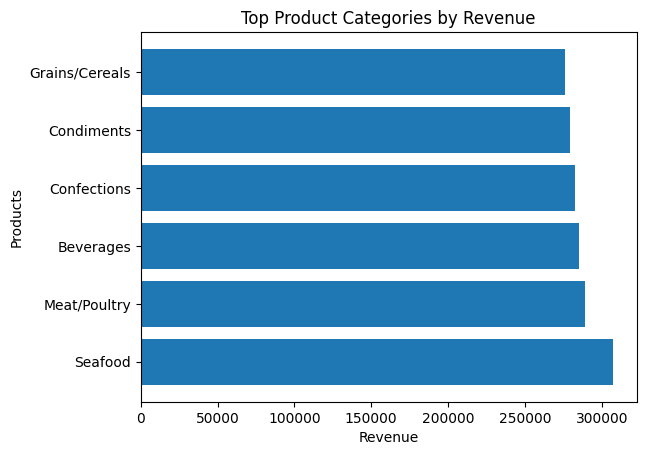

In [12]:
plt.figure()
plt.barh(top_products['category_name'], top_products['revenue'])
plt.title("Top Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Products")
plt.show()

- `Monthly Revenue Trend`

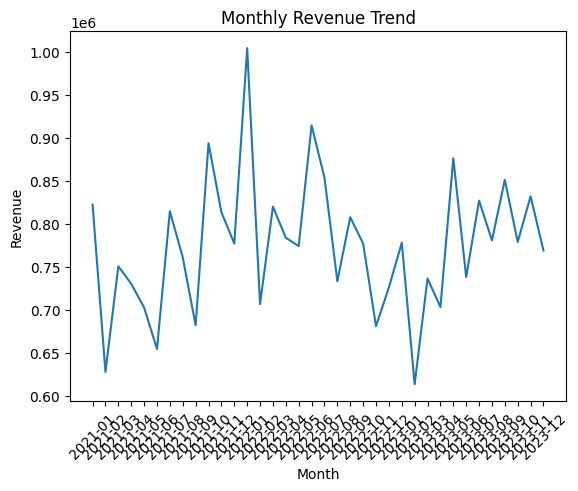

In [13]:
plt.figure()
plt.plot(monthly_revenue['month'], monthly_revenue['revenue'])
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

- `Country Revenue`

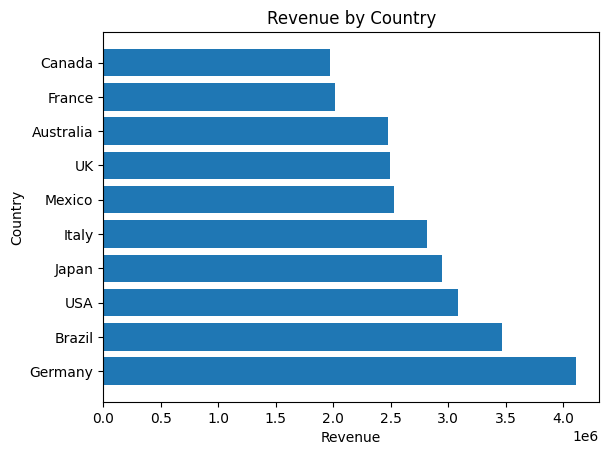

In [14]:
plt.figure()
plt.barh(country_rev['country'], country_rev['revenue'])
plt.title("Revenue by Country")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()

In [15]:
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9
})

- `FIGURE — Top Products + Revenue Share`

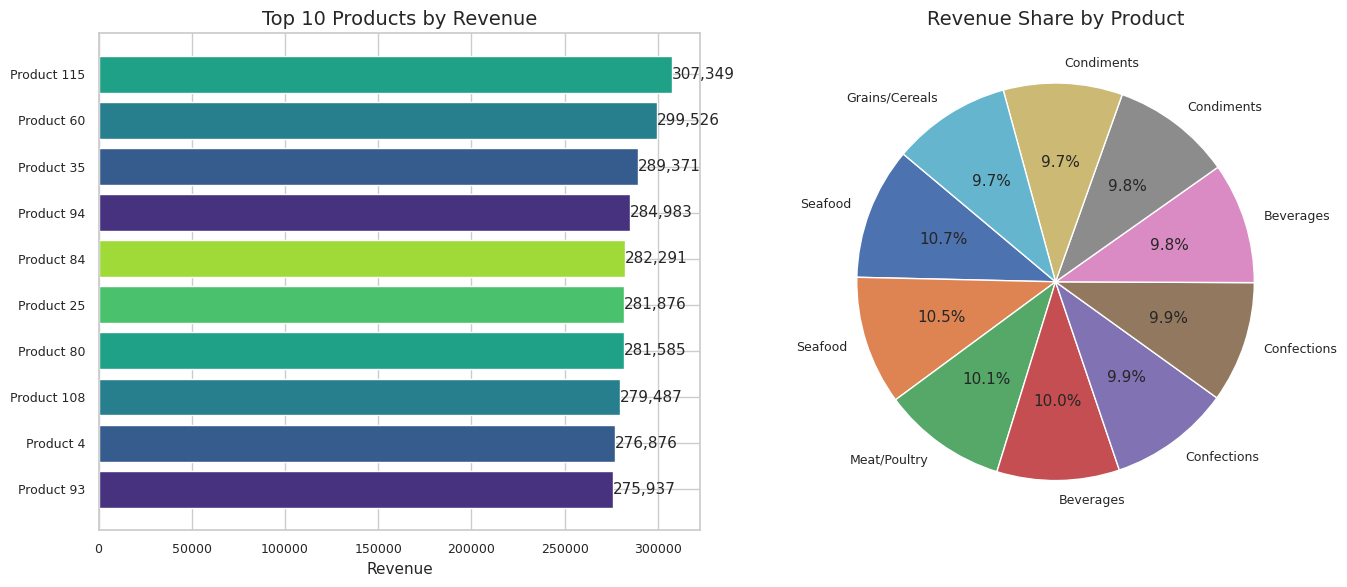

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- LEFT: Horizontal Bar ---
top_products_sorted = top_products.sort_values(by="revenue")

colors = sns.color_palette('viridis')

axes[0].barh(top_products_sorted['product_name'],
             top_products_sorted['revenue'], color=colors)

axes[0].set_title("Top 10 Products by Revenue")
axes[0].set_xlabel("Revenue")

# Add labels on bars
for i, v in enumerate(top_products_sorted['revenue']):
    axes[0].text(v, i, f"{v:,.0f}", va='center')

# --- RIGHT: Pie Chart ---
axes[1].pie(top_products['revenue'],
            labels=top_products['category_name'],
            autopct='%1.1f%%',
            startangle=140)

axes[1].set_title("Revenue Share by Product")

plt.tight_layout()
plt.savefig("figure1_products.png", dpi=300)
plt.show()

- `FIGURE — Monthly Trend + Rolling Average`

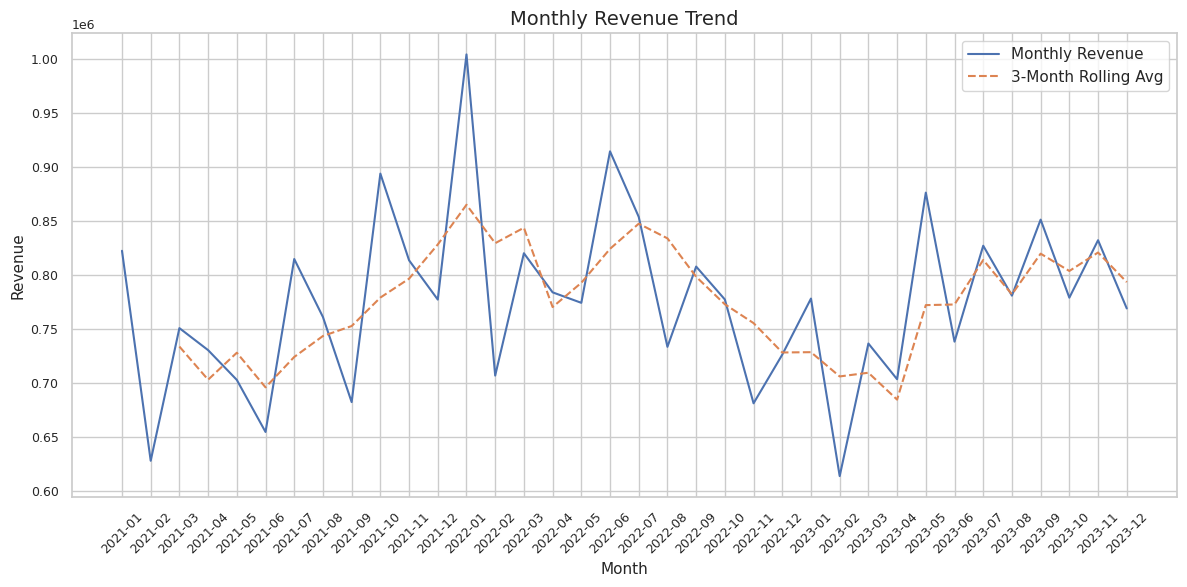

In [17]:
monthly_revenue['rolling_avg'] = monthly_revenue['revenue'].rolling(3).mean()

plt.figure(figsize=(12, 6))

# Revenue line
plt.plot(monthly_revenue['month'],
         monthly_revenue['revenue'],
         label="Monthly Revenue")

# Rolling avg line
plt.plot(monthly_revenue['month'],
         monthly_revenue['rolling_avg'],
         linestyle='--',
         label="3-Month Rolling Avg")

plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()

plt.tight_layout()
plt.savefig("figure2_trend.png", dpi=300)
plt.show()

- `FIGURE — Employee Ranking`

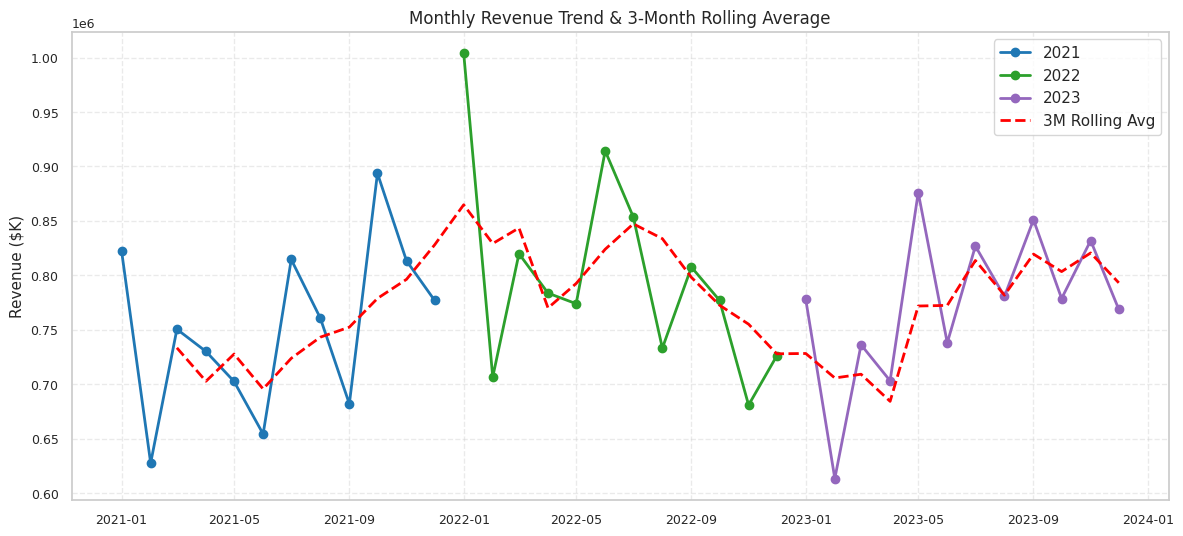

In [18]:
# ---------------------------
# STEP 1: PREP DATA
# ---------------------------
monthly_revenue['month'] = pd.to_datetime(monthly_revenue['month'])
monthly_revenue = monthly_revenue.sort_values('month')

# Extract year
monthly_revenue['year'] = monthly_revenue['month'].dt.year

# Rolling average (3 months)
monthly_revenue['rolling_avg'] = monthly_revenue['revenue'].rolling(3).mean()

# ---------------------------
# STEP 2: COLORS (MATCH IMAGE)
# ---------------------------
year_colors = {
    2021: '#1f77b4',   # blue
    2022: '#2ca02c',   # green
    2023: '#9467bd'    # purple
}

# ---------------------------
# STEP 3: FIGURE LAYOUT
# ---------------------------
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 1, height_ratios=[2, 1])

ax1 = fig.add_subplot(gs[0])

# ---------------------------
# TOP PLOT (MULTI-YEAR LINES)
# ---------------------------
for year in sorted(monthly_revenue['year'].unique()):
    df_year = monthly_revenue[monthly_revenue['year'] == year]

    ax1.plot(df_year['month'],
             df_year['revenue'],
             marker='o',
             linewidth=2,
             label=str(year),
             color=year_colors.get(year, 'black'))

# Rolling average (red dashed)
ax1.plot(monthly_revenue['month'],
         monthly_revenue['rolling_avg'],
         linestyle='--',
         linewidth=2,
         color='red',
         label='3M Rolling Avg')

ax1.set_title("Monthly Revenue Trend & 3-Month Rolling Average", fontsize=12)
ax1.set_ylabel("Revenue ($K)")
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### `FIGURE — Employee Performance by Country`

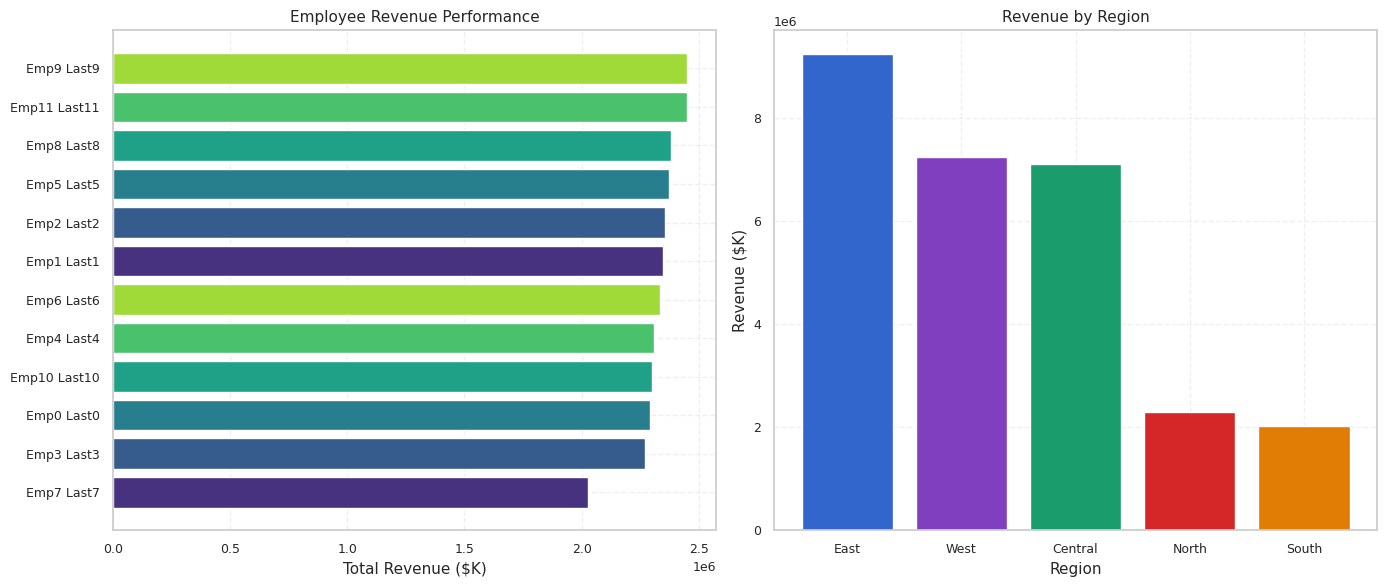

In [19]:
# ---------------------------
# STEP 1: EMPLOYEE DATA
# ---------------------------
employee_perf = pd.read_sql("""
SELECT e.first_name || ' ' || e.last_name AS Employee,
       SUM(o_i.unit_price * o_i.quantity) AS revenue
FROM employees e
JOIN orders o ON e.employee_id = o.employee_id
JOIN order_items o_i ON o.order_id = o_i.order_id
GROUP BY Employee
ORDER BY revenue DESC;
""", conn)

# Sort ascending for horizontal bar
employee_perf = employee_perf.sort_values('revenue')

# ---------------------------
# STEP 2: REGION DATA
# ---------------------------
region_rev = pd.read_sql("""
SELECT e.region,
       SUM(o_i.unit_price * o_i.quantity) AS revenue
FROM employees e
JOIN orders o ON e.employee_id = o.employee_id
JOIN order_items o_i ON o.order_id = o_i.order_id
GROUP BY e.region
ORDER BY revenue DESC;
""", conn)

# ---------------------------
# STEP 3: FIGURE LAYOUT
# ---------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ---------------------------
# LEFT: Employee Ranking
# ---------------------------

ax1.barh(employee_perf['Employee'],
         employee_perf['revenue'],
         color=sns.color_palette('viridis'))

ax1.set_title("Employee Revenue Performance", fontsize=11)
ax1.set_xlabel("Total Revenue ($K)")

# Grid
ax1.grid(True, linestyle='--', alpha=0.3)

# ---------------------------
# RIGHT: Revenue by Region
# ---------------------------

region_colors = ['#3366cc', '#7f3fbf', '#1a9c6c', '#d62728', '#e17c05']

ax2.bar(region_rev['region'],
        region_rev['revenue'],
        color=region_colors[:len(region_rev)])

ax2.set_title("Revenue by Region", fontsize=11)
ax2.set_xlabel("Region")
ax2.set_ylabel("Revenue ($K)")

ax2.grid(True, linestyle='--', alpha=0.3)

# ---------------------------
# FINAL TOUCH
# ---------------------------
plt.tight_layout()
plt.show()

- `Inventory Status Data`

In [20]:
inventory_query = """
SELECT
    p.product_id,
    p.product_name,
    p.units_in_stock,
    SUM(o_i.quantity) AS units_sold,

    CASE
        WHEN p.units_in_stock = 0 THEN 'Out of Stock'
        WHEN p.units_in_stock < 20 THEN 'Critical'
        WHEN p.units_in_stock < 50 THEN 'Low'
        WHEN p.units_in_stock < 100 THEN 'Healthy'
        ELSE 'Overstock'
    END AS stock_status

FROM products p
LEFT JOIN order_items o_i ON p.product_id = o_i.product_id
GROUP BY p.product_id;
"""

inventory_df = pd.read_sql(inventory_query, conn)

In [21]:
inventory_df

,product_id,product_name,units_in_stock,units_sold,stock_status
0,1,Product 0,117,1512,Overstock
1,2,Product 1,139,2107,Overstock
2,3,Product 2,36,2086,Low
3,4,Product 3,2,2187,Critical
4,5,Product 4,137,2193,Overstock
...,...,...,...,...,...
115,116,Product 115,5,2230,Critical
116,117,Product 116,58,1423,Healthy
117,118,Product 117,88,1677,Healthy
118,119,Product 118,132,2031,Overstock


In [22]:
status_counts = inventory_df['stock_status'].value_counts().reindex([
    'Out of Stock', 'Critical', 'Low', 'Healthy', 'Overstock'
])


category_query = """
SELECT c.category_name,
       SUM(o_i.quantity) AS total_units
FROM categories c
JOIN products p ON c.category_id = p.category_id
JOIN order_items o_i ON p.product_id = o_i.product_id
GROUP BY c.category_name
ORDER BY total_units DESC;
"""

category_df = pd.read_sql(category_query, conn)

In [23]:
category_df

,category_name,total_units
0,Condiments,38182
1,Beverages,32624
2,Confections,29336
3,Grains/Cereals,27999
4,Seafood,27707
5,Dairy Products,27462
6,Meat/Poultry,22264
7,Produce,16196


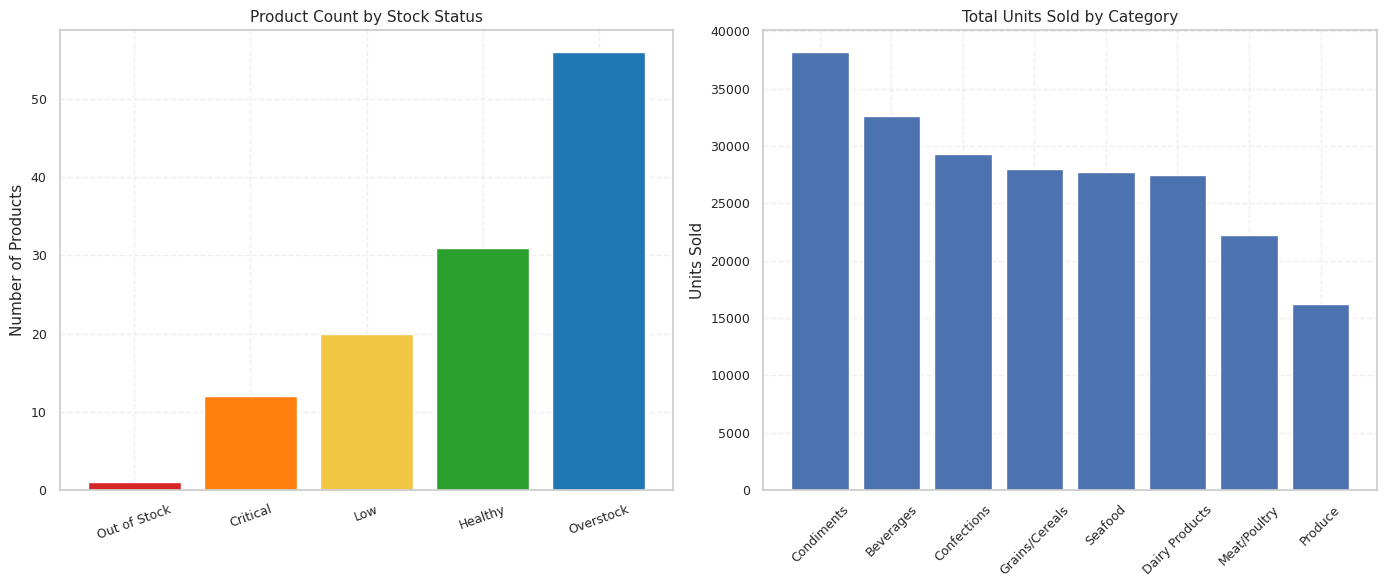

In [24]:
# ---------------------------
# FIGURE LAYOUT
# ---------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

# ---------------------------
# LEFT: Stock Status
# ---------------------------
colors_left = ['#d62728', '#ff7f0e', '#f2c744', '#2ca02c', '#1f77b4']

ax1.bar(status_counts.index, status_counts.values, color=colors_left)

ax1.set_title("Product Count by Stock Status", fontsize=11)
ax1.set_ylabel("Number of Products")
ax1.tick_params(axis='x', rotation=20)

ax1.grid(True, linestyle='--', alpha=0.3)

# ---------------------------
# RIGHT: Category Units Sold
# ---------------------------
ax2.bar(category_df['category_name'],
        category_df['total_units'])

ax2.set_title("Total Units Sold by Category", fontsize=11)
ax2.set_ylabel("Units Sold")

ax2.tick_params(axis='x', rotation=45)

ax2.grid(True, linestyle='--', alpha=0.3)

# ---------------------------
# FINAL TOUCH
# ---------------------------
plt.tight_layout()
plt.show()

In [25]:
clv_query = """
WITH customer_ltv AS (
    SELECT c.customer_id,
           SUM(o_i.unit_price * o_i.quantity) AS total_spent,
           COUNT(DISTINCT o.order_id) AS total_orders
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    JOIN order_items o_i ON o.order_id = o_i.order_id
    GROUP BY c.customer_id
),
ranked AS (
    SELECT *,
           NTILE(4) OVER (ORDER BY total_spent DESC) AS tier
    FROM customer_ltv
)
SELECT *,
       CASE
           WHEN tier = 1 THEN 'Platinum'
           WHEN tier = 2 THEN 'Gold'
           WHEN tier = 3 THEN 'Silver'
           ELSE 'Bronze'
       END AS segment,
       total_spent / total_orders AS avg_order_value
FROM ranked;
"""

clv_df = pd.read_sql(clv_query, conn)

In [26]:
clv_df

,customer_id,total_spent,total_orders,tier,segment,avg_order_value
0,CUST0171,206235.29,31,1,Platinum,6652.751290
1,CUST0058,172891.94,26,1,Platinum,6649.690000
2,CUST0195,170062.82,31,1,Platinum,5485.897419
3,CUST0245,169378.67,27,1,Platinum,6273.284074
4,CUST0136,166354.36,28,1,Platinum,5941.227143
...,...,...,...,...,...,...
295,CUST0273,43182.49,11,4,Bronze,3925.680909
296,CUST0036,42933.15,11,4,Bronze,3903.013636
297,CUST0118,33927.07,8,4,Bronze,4240.883750
298,CUST0194,32361.65,6,4,Bronze,5393.608333


In [27]:
# Revenue by segment
rev_segment = clv_df.groupby('segment')['total_spent'].sum().reindex(
    ['Platinum','Gold','Silver','Bronze'])

# Avg order value by segment
aov_segment = clv_df.groupby('segment')['avg_order_value'].mean().reindex(
    ['Platinum','Gold','Silver','Bronze'])

In [28]:
rev_segment

,total_spent
segment,
Platinum,9797914.32
Gold,7540670.00
Silver,6076038.83
Bronze,4476974.52


In [29]:
aov_segment

,avg_order_value
segment,
Platinum,6298.267752
Gold,5799.245352
Silver,5335.879599
Bronze,4851.622271


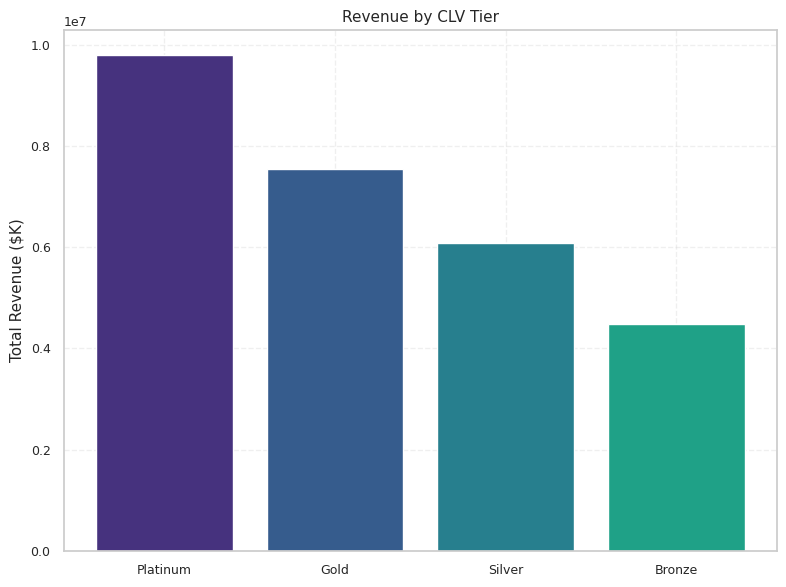

In [30]:
# Layout
fig, ax = plt.subplots(1, 1, figsize=(8,6))

# Revenue by CLV Tier
ax.bar(rev_segment.index, rev_segment.values, color=sns.color_palette('viridis'))

ax.set_title("Revenue by CLV Tier", fontsize=11)
ax.set_ylabel("Total Revenue ($K)")
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()